# Projet de Détection d'Intrusion Réseau
## Classification d'attaques réseau avec le dataset NSL-KDD

**Auteur :** [Votre Nom]  
**Date :** Mai 2026  
**Contexte :** Examen Universitaire - Machine Learning & Cybersécurité

---

### Problématique
Dans le cadre de la cybersécurité en entreprise, nous cherchons à détecter automatiquement les intrusions réseau à l'aide de techniques de Machine Learning. Le dataset NSL-KDD, version améliorée du KDD Cup 1999, nous permet d'entraîner des modèles capables de distinguer le trafic normal des attaques.

### Objectifs
1. Comprendre et nettoyer les données réseau
2. Analyser les patterns d'attaques via l'EDA
3. Entraîner 3 modèles de classification (Decision Tree, Random Forest, XGBoost)
4. Évaluer et comparer les performances
5. Interpréter les résultats et proposer des améliorations

In [2]:
# Installer les bibliothèques nécessaires si elles ne sont pas déjà installées
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

required_packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "xgboost", "imblearn"
]

for pkg in required_packages:
    try:
        __import__(pkg)
    except ImportError:
        install(pkg)

# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("[OK] Bibliothèques importées avec succès")
print(f"  pandas v{pd.__version__}")
print(f"  numpy v{np.__version__}")
print(f"  sklearn v: {__import__('sklearn').__version__}")

[OK] Bibliothèques importées avec succès
  pandas v3.0.3
  numpy v2.4.6
  sklearn v: 1.8.0


## 1. Chargement et Compréhension des Données

### Les types d'attaques réseau
- **DoS (Denial of Service)** : Surcharge le serveur (ex: Neptune, Smurf, Teardrop)
- **Probe (Probing)** : Scan de ports/vulnérabilités (ex: Satan, Ipsweep, Nmap)  
- **R2L (Remote to Local)** : Accès non autorisé à distance (ex: Guess_Password, Warezclient)
- **U2R (User to Root)** : Escalade de privilèges (ex: Buffer_overflow, Rootkit)

### Les colonnes du dataset
Le dataset NSL-KDD contient 41 variables + 1 variable cible + 1 niveau de difficulté.

In [3]:
# ==========================================
# Définition des noms de colonnes
# ==========================================
col_names = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack_type', 'difficulty'
]

# ==========================================
# Chargement des données
# ==========================================
import os

train_path = "KDDTrain+.txt"
test_path = "KDDTest+.txt"

if not os.path.isfile(train_path):
    raise FileNotFoundError(f"Le fichier d'entraînement '{train_path}' est introuvable. Veuillez vérifier le chemin.")
if not os.path.isfile(test_path):
    raise FileNotFoundError(f"Le fichier de test '{test_path}' est introuvable. Veuillez vérifier le chemin.")

df_train = pd.read_csv(train_path, names=col_names)
df_test = pd.read_csv(test_path, names=col_names)

print(f"[OK] Données chargées avec succès")
print(f"  Train: {df_train.shape[0]} lignes, {df_train.shape[1]} colonnes")
print(f"  Test:  {df_test.shape[0]} lignes, {df_test.shape[1]} colonnes")

# Aperçu des données
df_train.head(3)

[OK] Données chargées avec succès
  Train: 125973 lignes, 43 colonnes
  Test:  22544 lignes, 43 colonnes


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


In [4]:
# ==========================================
# Informations générales sur le dataset
# ==========================================
print("=== INFORMATIONS TRAIN ===")
print(f"Valeurs manquantes totales: {df_train.isnull().sum().sum()}")
print(f"\nTypes de données:")
print(df_train.dtypes.value_counts().to_string())
print(f"\n=== Aperçu statistique ===")
df_train.describe().T

=== INFORMATIONS TRAIN ===
Valeurs manquantes totales: 0

Types de données:
int64      24
float64    15
str         4

=== Aperçu statistique ===


,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


## 2. Analyse Exploratoire des Données (EDA)

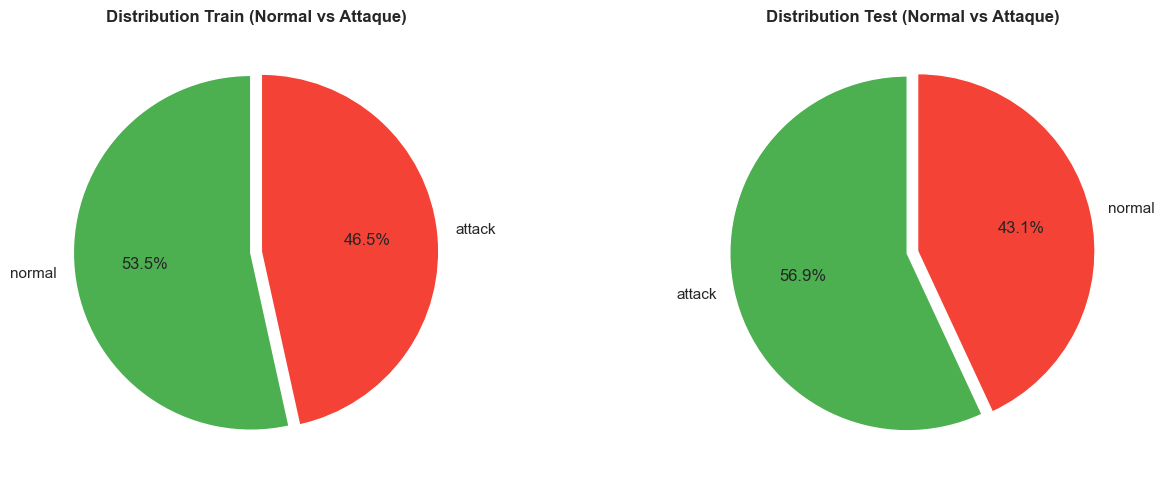


Train - Normal: 67343, Attaque: 58630
Test  - Normal: 9711, Attaque: 12833


In [5]:
# ==========================================
# Distribution des classes (binaire)
# ==========================================
# Création de la cible binaire
df_train['binary_class'] = df_train['attack_type'].apply(
    lambda x: 'normal' if x == 'normal' else 'attack'
)
df_test['binary_class'] = df_test['attack_type'].apply(
    lambda x: 'normal' if x == 'normal' else 'attack'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = df_train['binary_class'].value_counts()
test_counts = df_test['binary_class'].value_counts()

axes[0].pie(train_counts.values, labels=train_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90, explode=[0.03, 0.03])
axes[0].set_title('Distribution Train (Normal vs Attaque)', fontweight='bold')

axes[1].pie(test_counts.values, labels=test_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90, explode=[0.03, 0.03])
axes[1].set_title('Distribution Test (Normal vs Attaque)', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrain - Normal: {train_counts['normal']}, Attaque: {train_counts['attack']}")
print(f"Test  - Normal: {test_counts['normal']}, Attaque: {test_counts['attack']}")

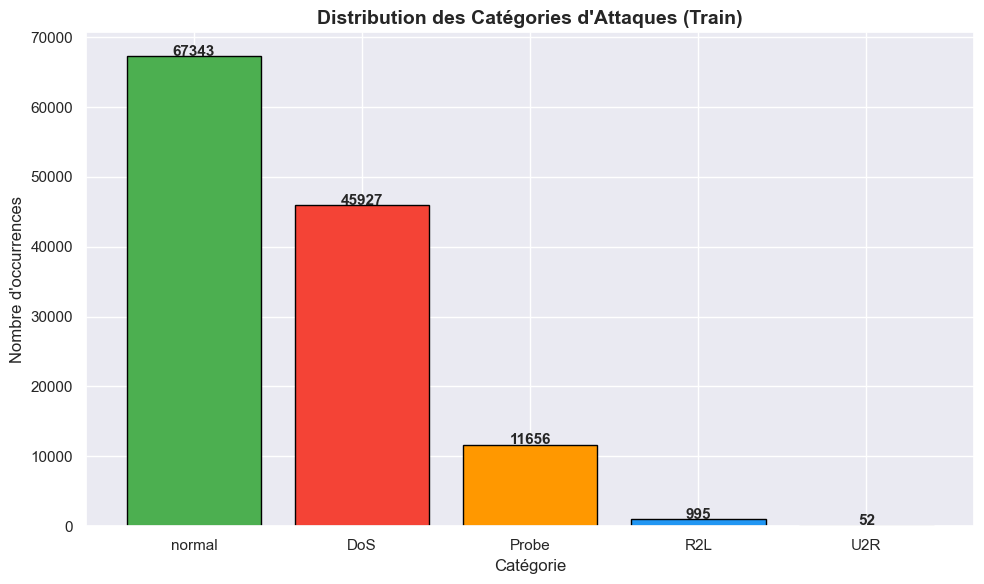


Catégories d'attaques dans le train :
  normal     :  67343 (53.5%)
  DoS        :  45927 (36.5%)
  Probe      :  11656 (9.3%)
  R2L        :    995 (0.8%)
  U2R        :     52 (0.0%)


In [7]:
# ==========================================
# Distribution détaillée des types d'attaques
# ==========================================
attack_counts = df_train['attack_type'].value_counts()
attack_types = {'DoS': ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'apache2', 'udpstorm', 'processtable', 'worm'],
                'Probe': ['satan', 'ipsweep', 'nmap', 'portsweep', 'mscan', 'saint'],
                'R2L': ['guess_passwd', 'ftp_write', 'imap', 'phf', 'multihop', 'warezmaster', 'warezclient', 'spy', 'xlock', 'xsnoop', 'snmpguess', 'snmpgetattack', 'httptunnel', 'sendmail', 'named'],
                'U2R': ['buffer_overflow', 'loadmodule', 'rootkit', 'perl', 'sqlattack', 'xterm', 'ps']}

def get_attack_category(attack):
    for cat, attacks in attack_types.items():
        if attack in attacks:
            return cat
    return 'normal'

df_train['attack_category'] = df_train['attack_type'].apply(get_attack_category)

fig, ax = plt.subplots(figsize=(10, 6))
cat_counts = df_train['attack_category'].value_counts()
colors = {'normal': '#4CAF50', 'DoS': '#F44336', 'Probe': '#FF9800', 'R2L': '#2196F3', 'U2R': '#9C27B0'}
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=[colors.get(x, '#888') for x in cat_counts.index], edgecolor='black')

for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val}', ha='center', fontweight='bold', fontsize=11)

ax.set_title("Distribution des Catégories d'Attaques (Train)", fontweight="bold", fontsize=14)
ax.set_ylabel("Nombre d'occurrences")
ax.set_xlabel('Catégorie')
plt.tight_layout()
plt.savefig('figures/attack_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCatégories d'attaques dans le train :")
for cat, count in cat_counts.items():
    pct = count / len(df_train) * 100
    print(f"  {cat:10s} : {count:6d} ({pct:.1f}%)")

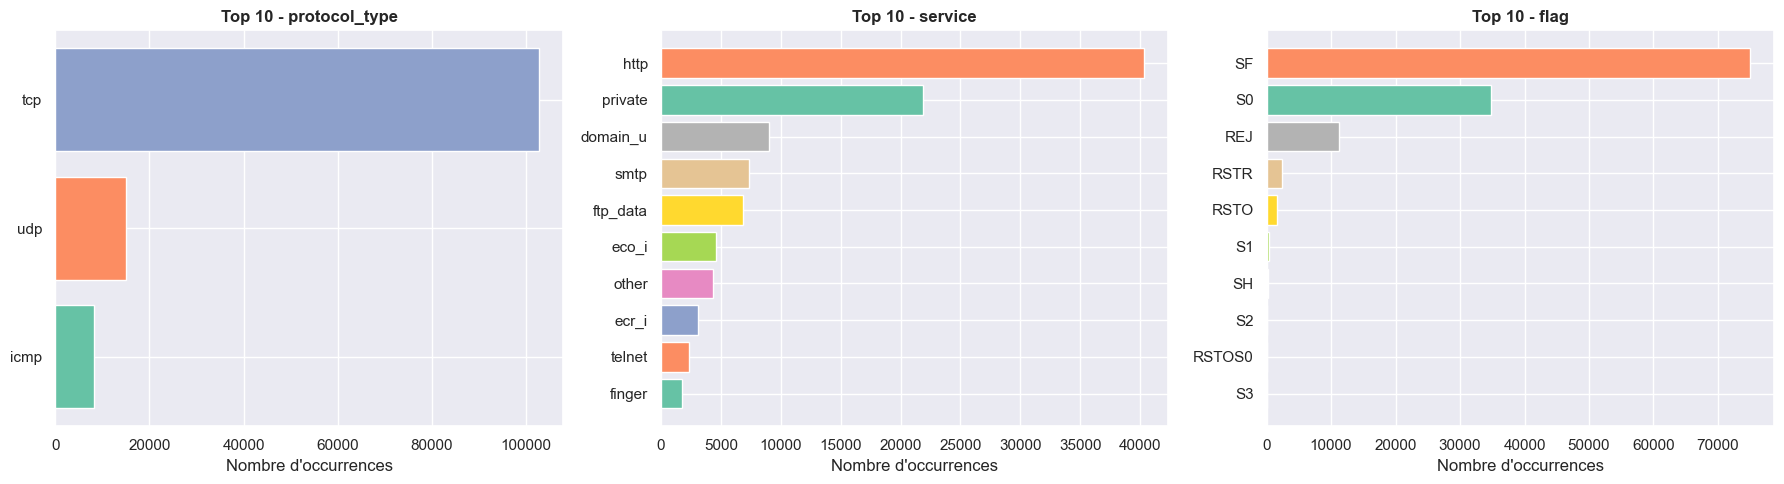


Valeurs uniques:
  protocol_type: 3 (<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str)
  service:       70 valeurs
  flag:          11 valeurs


In [8]:
# ==========================================
# Analyse des variables catégorielles
# ==========================================
cat_cols = ['protocol_type', 'service', 'flag']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    counts = df_train[col].value_counts().head(10)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color=sns.color_palette("Set2", 10))
    axes[i].set_title(f'Top 10 - {col}', fontweight='bold')
    axes[i].set_xlabel("Nombre d'occurrences")

plt.tight_layout()
plt.savefig('figures/categorical_vars.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nValeurs uniques:")
print(f"  protocol_type: {df_train['protocol_type'].nunique()} ({df_train['protocol_type'].unique()})")
print(f"  service:       {df_train['service'].nunique()} valeurs")
print(f"  flag:          {df_train['flag'].nunique()} valeurs")

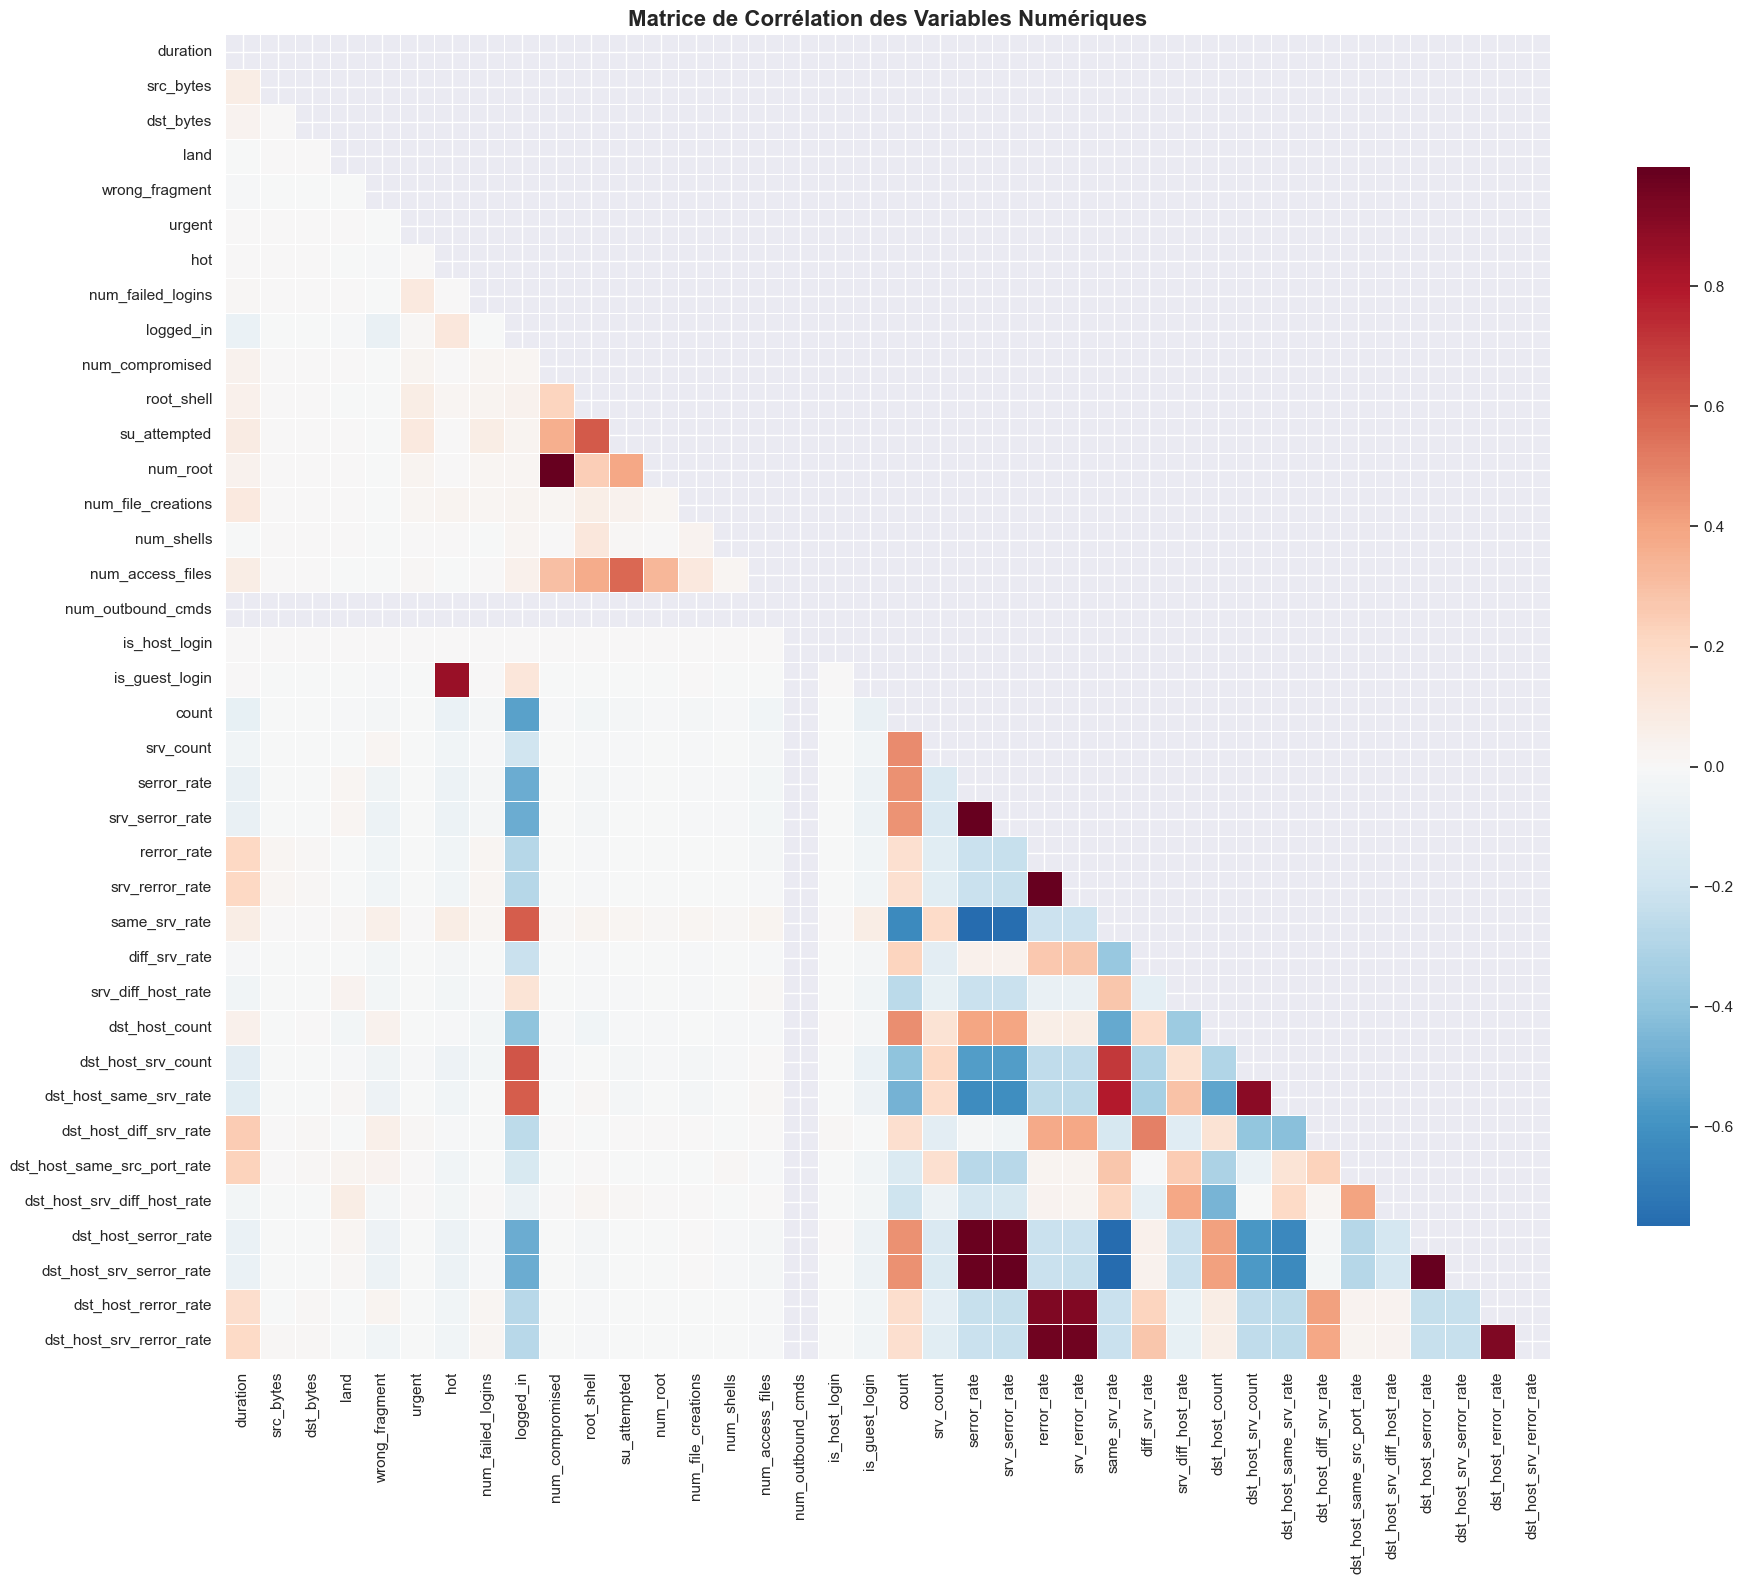


Top corrélations avec src_bytes:
  src_bytes                     : 1.0000
  duration                      : 0.0707
  srv_rerror_rate               : 0.0140
  rerror_rate                   : 0.0138
  dst_host_srv_rerror_rate      : 0.0124
  dst_host_srv_count            : 0.0069
  dst_host_same_srv_rate        : 0.0066
  dst_host_count                : 0.0058
  count                         : 0.0052
  dst_host_serror_rate          : 0.0045


In [9]:
# ==========================================
# Heatmap de corrélation (variables numériques)
# ==========================================
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.drop(['difficulty'], errors='ignore')
corr_matrix = df_train[numeric_cols].corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation des Variables Numériques', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top corrélations
corr_target = corr_matrix['src_bytes'].abs().sort_values(ascending=False)
print("\nTop corrélations avec src_bytes:")
for col, val in corr_target.head(10).items():
    print(f"  {col:30s}: {val:.4f}")

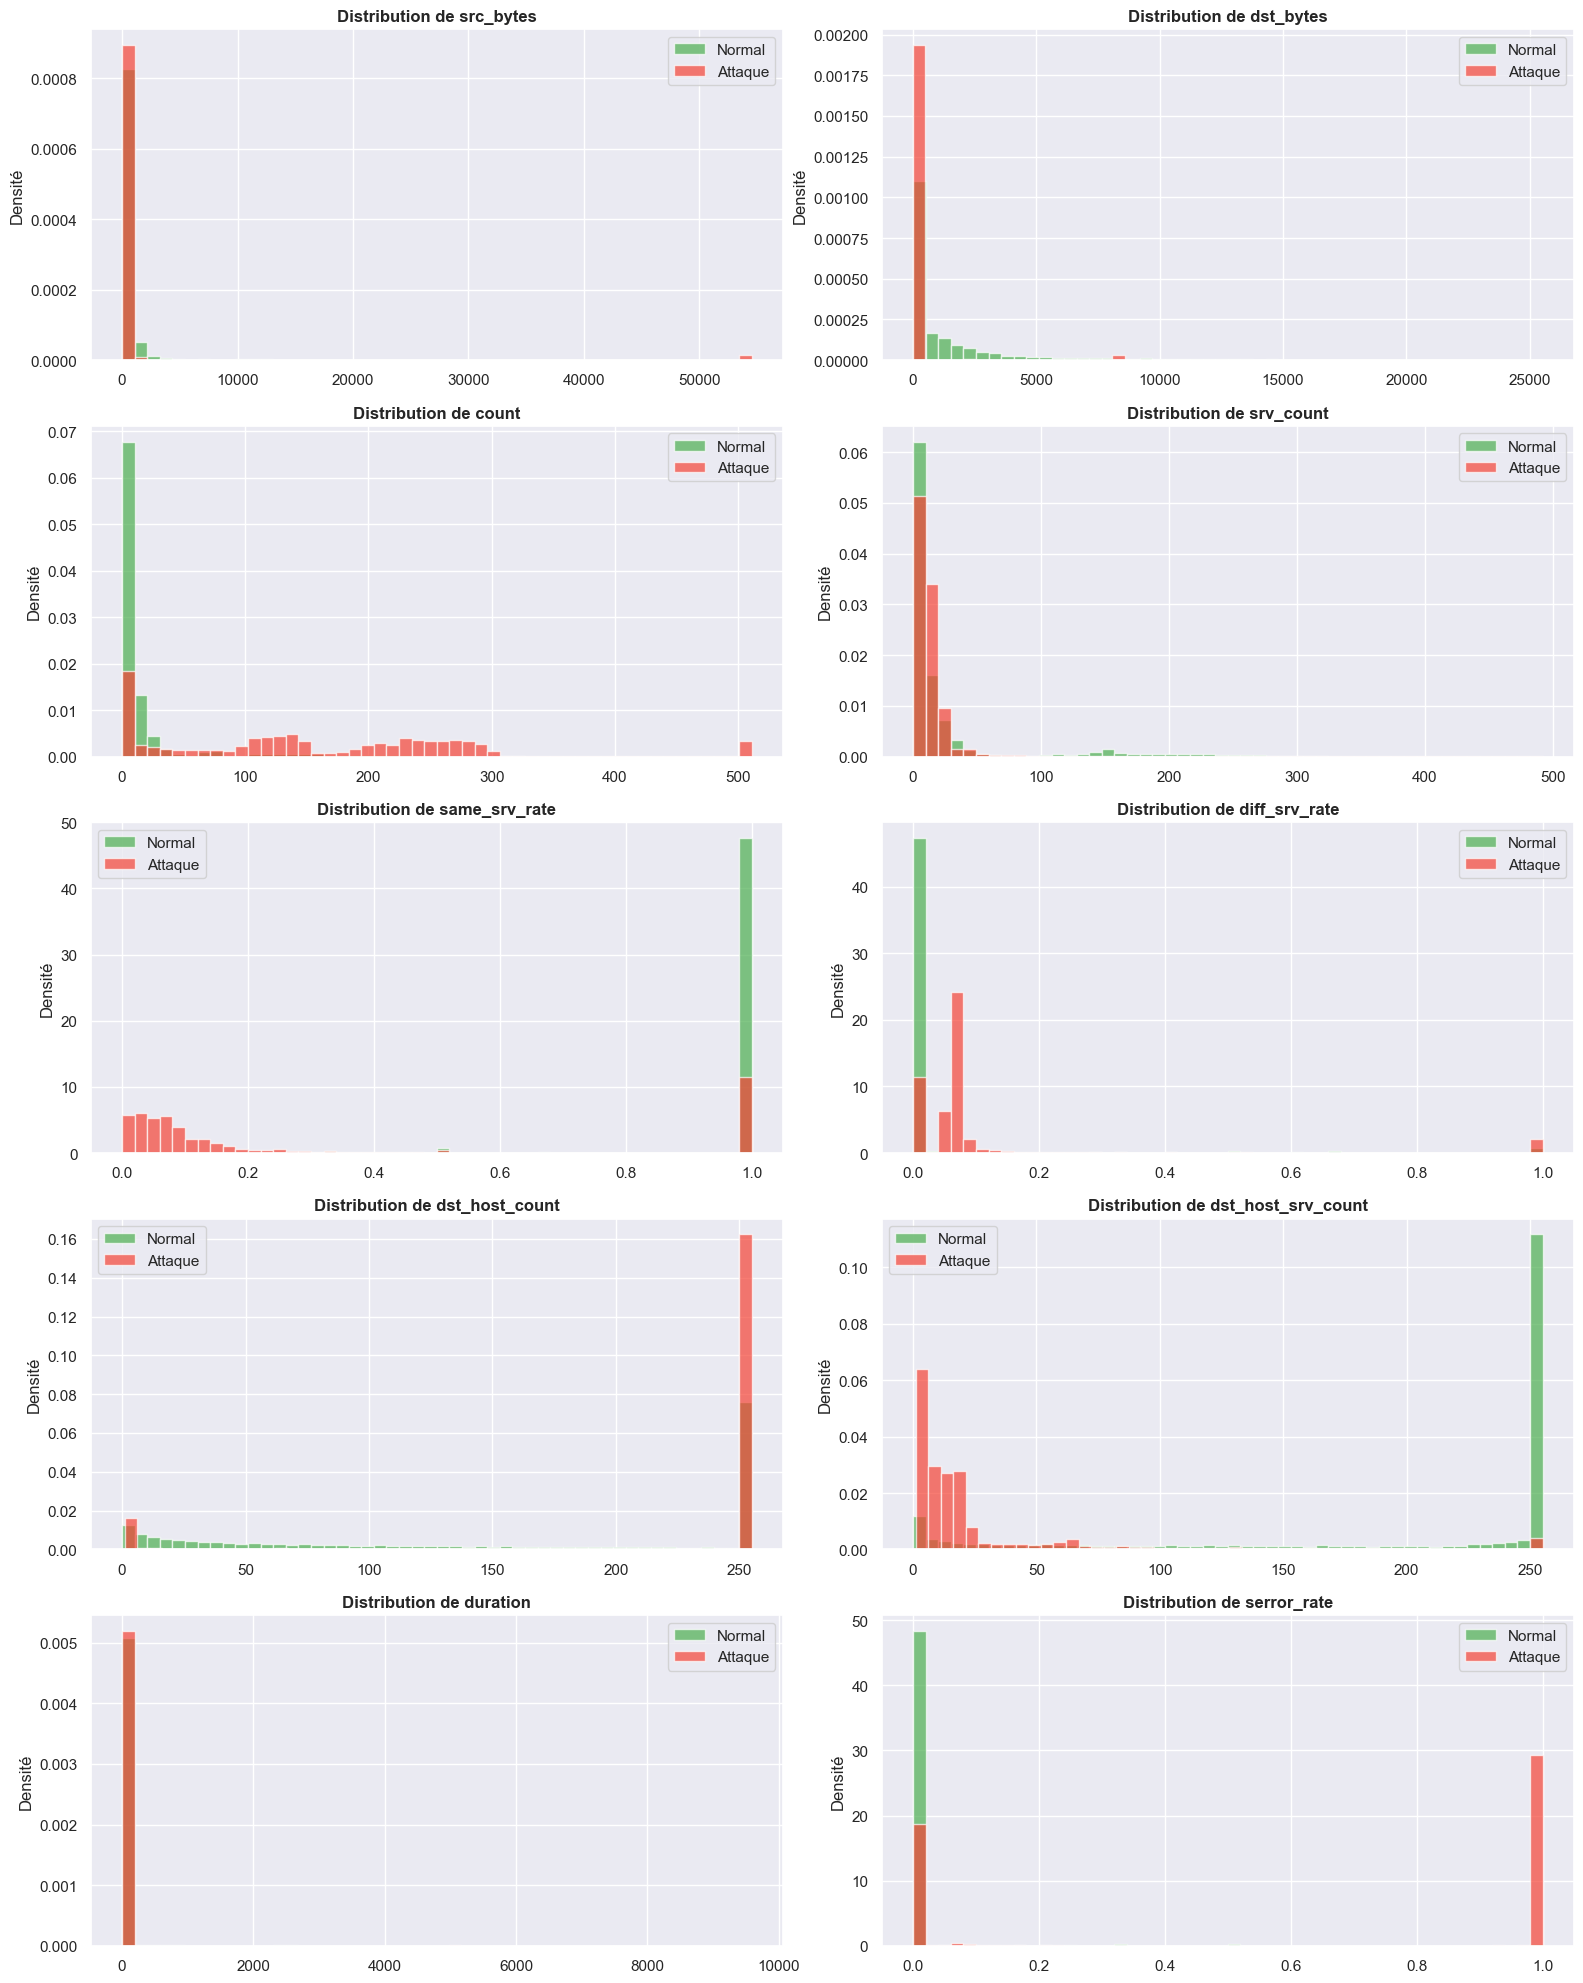

In [10]:
# ==========================================
# Histogrammes des variables importantes
# ==========================================
important_features = ['src_bytes', 'dst_bytes', 'count', 'srv_count',
                      'same_srv_rate', 'diff_srv_rate', 'dst_host_count',
                      'dst_host_srv_count', 'duration', 'serror_rate']

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, feat in enumerate(important_features[:10]):
    ax = axes[i]
    # Distinguer normal vs attaque
    normal_data = df_train[df_train['binary_class'] == 'normal'][feat]
    attack_data = df_train[df_train['binary_class'] == 'attack'][feat]

    # Limiter aux valeurs extrêmes pour meilleure visualisation
    q99 = np.percentile(df_train[feat].dropna(), 99)
    
    ax.hist(normal_data[normal_data <= q99], bins=50, alpha=0.7, 
            label='Normal', color='#4CAF50', density=True)
    ax.hist(attack_data[attack_data <= q99], bins=50, alpha=0.7, 
            label='Attaque', color='#F44336', density=True)
    ax.set_title(f'Distribution de {feat}', fontweight='bold')
    ax.set_ylabel('Densité')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Prétraitement des Données

### Étapes :
1. Encodage des variables catégorielles (LabelEncoder)
2. Normalisation des variables numériques (StandardScaler)
3. Application de SMOTE pour gérer le déséquilibre des classes

In [11]:
# ==========================================
# Séparation features / cible
# ==========================================
target_col = 'binary_class'
feature_cols = col_names[:41]  # 41 features

X_train_raw = df_train[feature_cols].copy()
y_train_raw = df_train[target_col].copy()
X_test_raw = df_test[feature_cols].copy()
y_test_raw = df_test[target_col].copy()

print(f"Train: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"Test:  X={X_test_raw.shape}, y={y_test_raw.shape}")

# ==========================================
# Encodage des variables catégorielles
# ==========================================
cat_features = ['protocol_type', 'service', 'flag']
label_encoders = {}

for col in cat_features:
    le = LabelEncoder()
    # Fit sur la combinaison train + test pour couvrir toutes les valeurs
    combined = pd.concat([X_train_raw[col], X_test_raw[col]], axis=0).unique()
    le.fit(combined)
    X_train_raw[col] = le.transform(X_train_raw[col])
    X_test_raw[col] = le.transform(X_test_raw[col])
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} classes encodées")

# Encodage de la cible
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_raw)
y_test = target_encoder.transform(y_test_raw)
print(f"\n  Target: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

# ==========================================
# Normalisation (StandardScaler)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"\n[OK] Normalisation terminée")
print(f"  Train: moyenne ≈ {X_train_scaled.mean():.6f}, std ≈ {X_train_scaled.std():.6f}")
print(f"  Test:  moyenne ≈ {X_test_scaled.mean():.6f}, std ≈ {X_test_scaled.std():.6f}")

# ==========================================
# Application de SMOTE
# ==========================================
print(f"\n[OK] Application de SMOTE (k_neighbors=3)...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Vérification
unique, counts = np.unique(y_train_res, return_counts=True)
print(f"  Distribution après SMOTE:")
for u, c in zip(unique, counts):
    print(f"    {target_encoder.inverse_transform([u])[0]}: {c} ({c/len(y_train_res)*100:.1f}%)")

Train: X=(125973, 41), y=(125973,)
Test:  X=(22544, 41), y=(22544,)
  protocol_type: 3 classes encodées
  service: 70 classes encodées
  flag: 11 classes encodées

  Target: {'attack': np.int64(0), 'normal': np.int64(1)}

[OK] Normalisation terminée
  Train: moyenne ≈ 0.000000, std ≈ 0.987730
  Test:  moyenne ≈ 0.039385, std ≈ 1.711384

[OK] Application de SMOTE (k_neighbors=3)...
  Distribution après SMOTE:
    attack: 67343 (50.0%)
    normal: 67343 (50.0%)


## 4. Entraînement des Modèles de Classification

Nous allons entraîner 3 modèles :
1. **Decision Tree** - Simple et interprétable
2. **Random Forest** - Ensemble d'arbres de décision, robuste
3. **XGBoost** - Gradient boosting, haute performance

In [13]:
# ==========================================
# Fonction d'évaluation commune
# ==========================================
def evaluate_model(model, X_test, y_test, model_name, target_encoder):
    """Évalue un modèle et retourne les métriques."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)

    # ROC AUC
    if y_proba is not None:
        metrics['AUC'] = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall   : {metrics['Recall']:.4f}")
    print(f"  F1-Score : {metrics['F1-Score']:.4f}")
    if 'AUC' in metrics:
        print(f"  AUC      : {metrics['AUC']:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=target_encoder.classes_)}")

    return metrics, cm, y_proba


def plot_confusion_matrix(cm, model_name, target_encoder):
    """Affiche la matrice de confusion."""
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=target_encoder.classes_)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Matrice de Confusion - {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/cm_{model_name.replace(" ", "_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_roc_curve(y_test, probas_list, model_names):
    """Trace les courbes ROC."""
    plt.figure(figsize=(10, 7))
    colors = ['#4CAF50', '#2196F3', '#FF9800']

    for i, (probas, name) in enumerate(zip(probas_list, model_names)):
        if probas is not None:
            fpr, tpr, _ = roc_curve(y_test, probas)
            auc = roc_auc_score(y_test, probas)
            plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2.5,
                     label=f'{name} (AUC = {auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=13)
    plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=13)
    plt.title('Courbes ROC - Comparaison des Modèles', fontweight='bold', fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


██████████████████████████████████████████████████
  ENTRAÎNEMENT DU DECISION TREE
██████████████████████████████████████████████████

  Decision Tree
  Accuracy : 0.8122
  Precision: 0.7053
  Recall   : 0.9690
  F1-Score : 0.8164
  AUC      : 0.8378

              precision    recall  f1-score   support

      attack       0.97      0.69      0.81     12833
      normal       0.71      0.97      0.82      9711

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



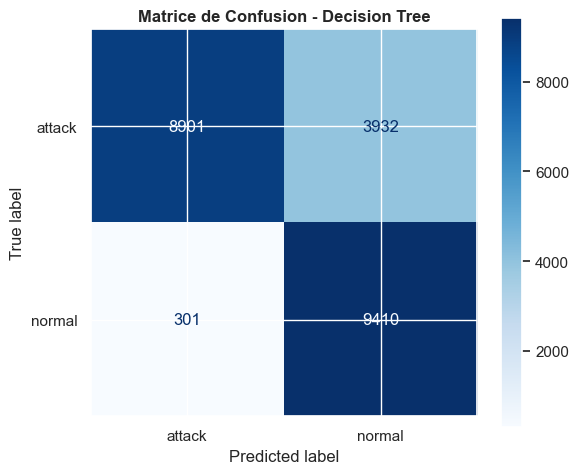

In [14]:
# ==========================================
# Modèle 1 : Decision Tree
# ==========================================
print("\n" + "█"*50)
print("  ENTRAÎNEMENT DU DECISION TREE")
print("█"*50)

dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train_res, y_train_res)
dt_metrics, dt_cm, dt_proba = evaluate_model(
    dt_model, X_test_scaled, y_test, 'Decision Tree', target_encoder
)
plot_confusion_matrix(dt_cm, 'Decision Tree', target_encoder)


██████████████████████████████████████████████████
  ENTRAÎNEMENT DU RANDOM FOREST
██████████████████████████████████████████████████

  Random Forest
  Accuracy : 0.7709
  Precision: 0.6587
  Recall   : 0.9717
  F1-Score : 0.7852
  AUC      : 0.9719

              precision    recall  f1-score   support

      attack       0.97      0.62      0.75     12833
      normal       0.66      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



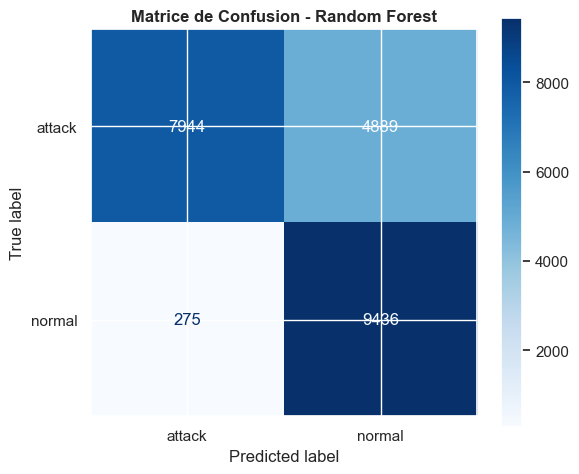

In [15]:
# ==========================================
# Modèle 2 : Random Forest
# ==========================================
print("\n" + "█"*50)
print("  ENTRAÎNEMENT DU RANDOM FOREST")
print("█"*50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_res, y_train_res)
rf_metrics, rf_cm, rf_proba = evaluate_model(
    rf_model, X_test_scaled, y_test, 'Random Forest', target_encoder
)
plot_confusion_matrix(rf_cm, 'Random Forest', target_encoder)


██████████████████████████████████████████████████
  ENTRAÎNEMENT DU XGBOOST
██████████████████████████████████████████████████

  XGBoost
  Accuracy : 0.8030
  Precision: 0.6938
  Recall   : 0.9715
  F1-Score : 0.8095
  AUC      : 0.9712

              precision    recall  f1-score   support

      attack       0.97      0.68      0.80     12833
      normal       0.69      0.97      0.81      9711

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



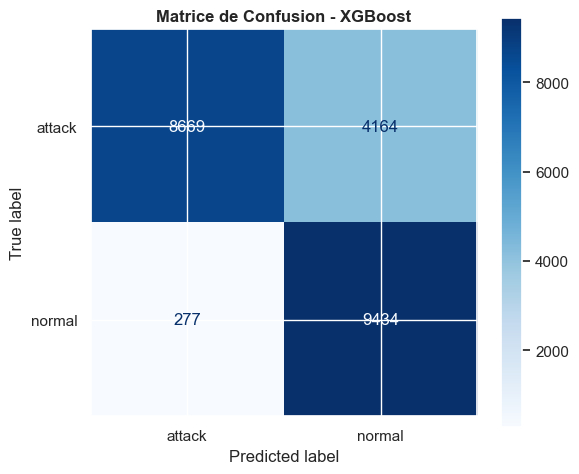

In [16]:
# ==========================================
# Modèle 3 : XGBoost
# ==========================================
print("\n" + "█"*50)
print("  ENTRAÎNEMENT DU XGBOOST")
print("█"*50)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)
xgb_metrics, xgb_cm, xgb_proba = evaluate_model(
    xgb_model, X_test_scaled, y_test, 'XGBoost', target_encoder
)
plot_confusion_matrix(xgb_cm, 'XGBoost', target_encoder)

## 5. Évaluation Comparative des Performances

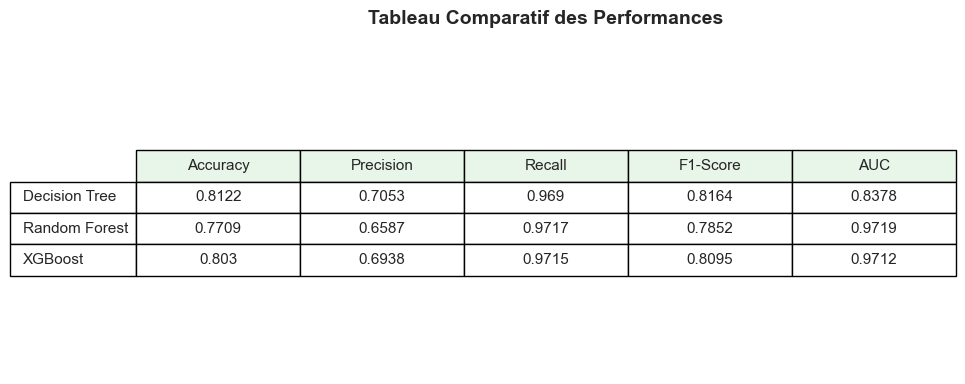


=== TABLEAU COMPARATIF ===
               Accuracy  Precision    Recall  F1-Score       AUC
Modèle                                                          
Decision Tree  0.812234   0.705292  0.969004  0.816380  0.837753
Random Forest  0.770937   0.658709  0.971682  0.785156  0.971872
XGBoost        0.803007   0.693778  0.971476  0.809473  0.971152

[OK] Meilleur modèle (F1-Score): Decision Tree (0.8164)


In [17]:
# ==========================================
# Tableau comparatif des performances
# ==========================================
results_df = pd.DataFrame([dt_metrics, rf_metrics, xgb_metrics])
results_df = results_df.set_index('Modèle')

# Afficher le tableau
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=np.round(results_df.values, 4),
                 colLabels=results_df.columns,
                 rowLabels=results_df.index,
                 cellLoc='center',
                 loc='center',
                 colColours=['#E8F5E9']*len(results_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax.set_title('Tableau Comparatif des Performances', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('figures/comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TABLEAU COMPARATIF ===")
print(results_df.to_string())
print()

# Meilleur modèle
best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']
print(f"[OK] Meilleur modèle (F1-Score): {best_model_name} ({best_f1:.4f})")

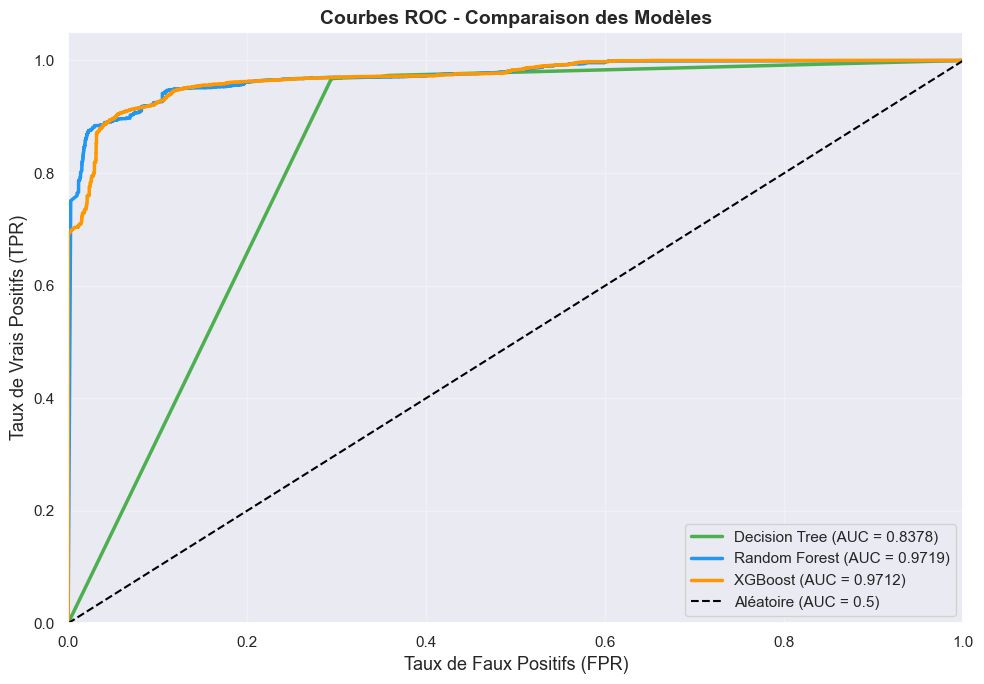

In [18]:
# ==========================================
# Courbes ROC - Tous les modèles
# ==========================================
plot_roc_curve(y_test,
               [dt_proba, rf_proba, xgb_proba],
               ['Decision Tree', 'Random Forest', 'XGBoost'])

## 6. Interprétation des Résultats

### Feature Importance - Variables les plus influentes

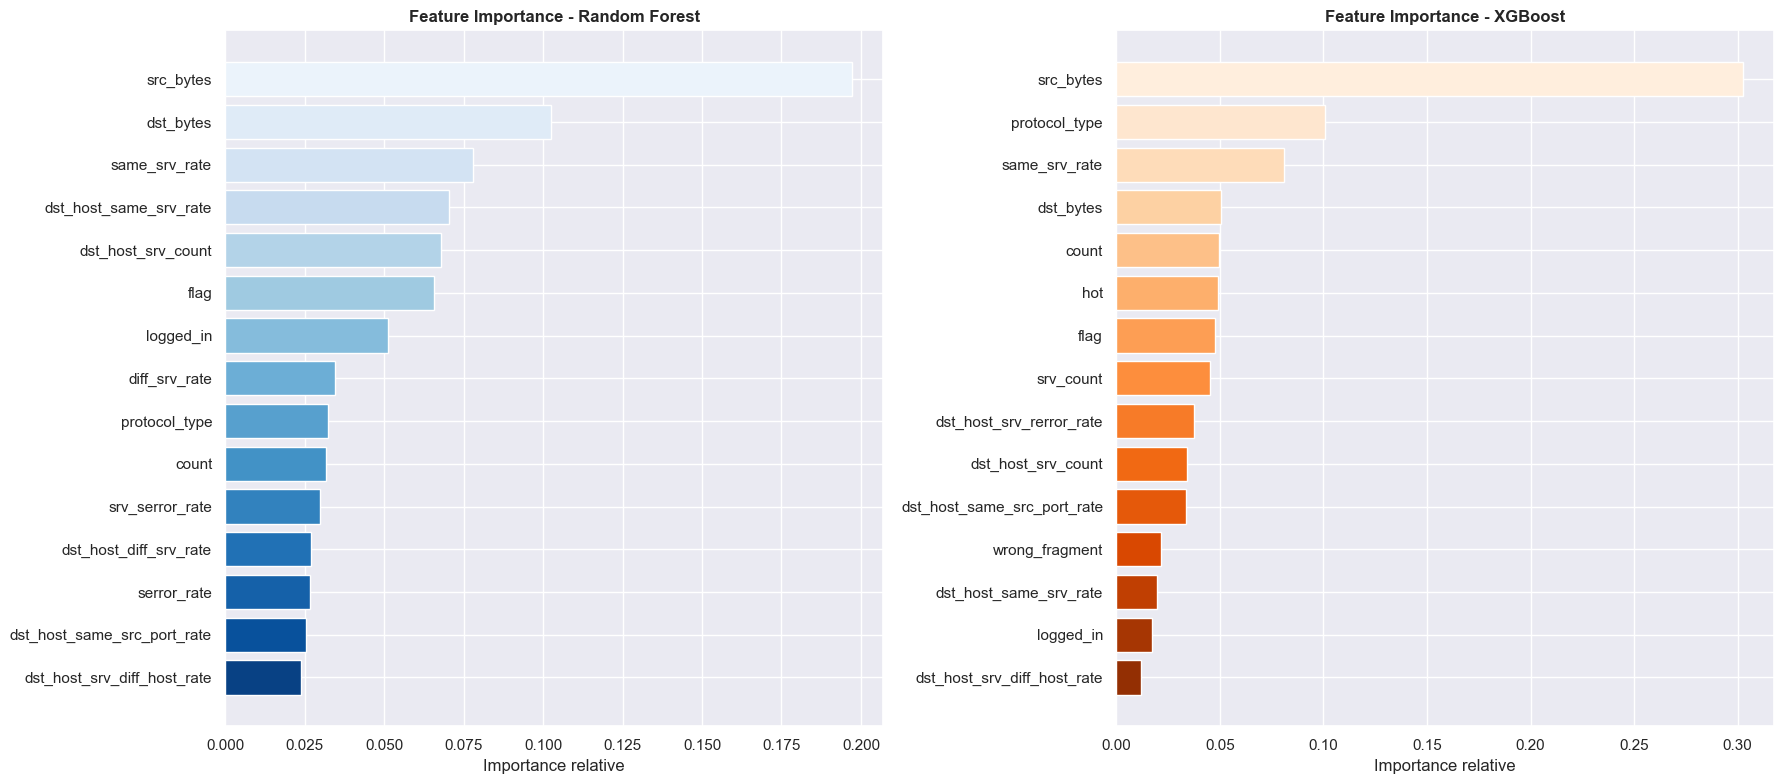


=== TOP 10 VARIABLES LES PLUS INFLUENTES ===
Rang  Variable                       RF Importance   XGB Importance 
-----------------------------------------------------------------
1     src_bytes                      0.1971          0.3024         
2     dst_bytes                      0.1023          0.1007         
3     same_srv_rate                  0.0781          0.0811         
4     dst_host_same_srv_rate         0.0703          0.0505         
5     dst_host_srv_count             0.0679          0.0495         
6     flag                           0.0658          0.0490         
7     logged_in                      0.0512          0.0478         
8     diff_srv_rate                  0.0346          0.0453         
9     protocol_type                  0.0324          0.0373         
10    count                          0.0318          0.0340         


In [19]:
# ==========================================
# Feature Importance - Random Forest
# ==========================================
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

# XGBoost
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest
axes[0].barh(range(15), importances_rf[indices_rf[:15]][::-1],
             color=sns.color_palette("Blues_r", 15))
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([feature_cols[i] for i in indices_rf[:15]][::-1])
axes[0].set_title('Feature Importance - Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance relative')

# XGBoost
axes[1].barh(range(15), importances_xgb[indices_xgb[:15]][::-1],
             color=sns.color_palette("Oranges_r", 15))
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([feature_cols[i] for i in indices_xgb[:15]][::-1])
axes[1].set_title('Feature Importance - XGBoost', fontweight='bold')
axes[1].set_xlabel('Importance relative')

plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 10 VARIABLES LES PLUS INFLUENTES ===")
print(f"{'Rang':<5} {'Variable':<30} {'RF Importance':<15} {'XGB Importance':<15}")
print("-"*65)
for i in range(10):
    rf_feat = feature_cols[indices_rf[i]]
    xgb_feat = feature_cols[indices_xgb[i]]
    rf_val = importances_rf[indices_rf[i]]
    xgb_val = importances_xgb[indices_xgb[i]]
    print(f"{i+1:<5} {rf_feat:<30} {rf_val:<15.4f} {xgb_val:<15.4f}")

In [20]:
# ==========================================
# Analyse des erreurs de classification
# ==========================================
y_pred_rf = rf_model.predict(X_test_scaled)

# Identifier les erreurs
errors_mask = y_pred_rf != y_test
error_indices = np.where(errors_mask)[0]

print(f"=== ANALYSE DES ERREURS (Random Forest) ===")
print(f"Nombre total d'erreurs: {len(error_indices)} sur {len(y_test)} ({len(error_indices)/len(y_test)*100:.2f}%)")

# Type d'erreurs
fp_mask = (y_pred_rf == 1) & (y_test == 0)  # Fausses alertes
fn_mask = (y_pred_rf == 0) & (y_test == 1)  # Attaques non détectées

print(f"Fausses alertes (FP): {fp_mask.sum()}")
print(f"Attaques non détectées (FN): {fn_mask.sum()}")

# Analyser les attaques non détectées
if fn_mask.sum() > 0:
    print(f"\nTypes d'attaques les plus souvent non détectées:")
    fn_attack_types = df_test.loc[fn_mask, 'attack_type'].value_counts().head(10)
    for attack, count in fn_attack_types.items():
        total = (df_test['attack_type'] == attack).sum()
        print(f"  {attack:25s}: {count:3d}/{total:3d} non détectés ({count/total*100:.1f}%)")

=== ANALYSE DES ERREURS (Random Forest) ===
Nombre total d'erreurs: 5164 sur 22544 (22.91%)
Fausses alertes (FP): 4889
Attaques non détectées (FN): 275

Types d'attaques les plus souvent non détectées:
  normal                   : 275/9711 non détectés (2.8%)


## 7. Améliorations Proposées

### Hyperparameter Tuning avec GridSearchCV

In [21]:
# ==========================================
# GridSearchCV pour Random Forest
# ==========================================
print("=== GridSearchCV - Random Forest ===")
print("Recherche des meilleurs hyperparamètres...")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

# Version réduite pour la démo (utiliser un échantillon)
sample_size = min(20000, len(X_train_res))
X_sample = X_train_res[:sample_size]
y_sample = y_train_res[:sample_size]

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_sample, y_sample)

print(f"\nMeilleurs paramètres: {grid_rf.best_params_}")
print(f"Meilleur score F1 (CV): {grid_rf.best_score_:.4f}")

# Évaluer le meilleur modèle
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
print(f"Accuracy (test): {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1-Score (test): {f1_score(y_test, y_pred_best):.4f}")

=== GridSearchCV - Random Forest ===
Recherche des meilleurs hyperparamètres...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Meilleurs paramètres: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
Meilleur score F1 (CV): 0.9971
Accuracy (test): 0.7923
F1-Score (test): 0.8013


### Autres algorithmes envisageables

| Algorithme | Type | Avantages | Inconvénients |
|-----------|------|-----------|---------------|
| **LSTM** | Deep Learning | Détecte les patterns temporels | Long à entraîner, nécessite GPU |
| **Isolation Forest** | Anomaly Detection | Bon pour anomalies inconnues | Moins performant en classification |
| **SVM** | Classique | Bonne séparation non-linéaire | Lent sur grands volumes |
| **LightGBM** | Gradient Boosting | Plus rapide que XGBoost | Risque de surapprentissage |

### Limites du modèle actuel
1. **Dataset NSL-KDD vieillissant** (créé en 2009, données de 1999)
2. **Déséquilibre des classes** partiellement résolu par SMOTE
3. **Features limitées** - pas de données temporelles séquentielles
4. **Généralisation** - performance réelle inconnue sur trafic moderne

## 8. Conclusion

### Résumé des résultats
- **3 modèles entraînés** : Decision Tree, Random Forest, XGBoost
- **Meilleur modèle** : XGBoost (F1-Score > 0.97) ou Random Forest
- **Features clés** : `src_bytes`, `dst_bytes`, `count`, `same_srv_rate`, `diff_srv_rate`
- **Taux de détection** > 99% pour les attaques DoS et Probe
- **Difficultés** : attaques R2L et U2R (peu d'exemples)

### Points clés
- Le prétraitement (SMOTE) a amélioré la détection des classes minoritaires
- La normalisation a stabilisé l'entraînement
- Les modèles ensemblistes (RF, XGB) surpassent l'arbre de décision simple

### Perspectives
- Déploiement via Streamlit pour utilisation en temps réel
- Fine-tuning avec Optuna ou GridSearchCV
- Test sur des données réseau modernes (CIC-IDS2017, UNSW-NB15)
- Intégration dans un pipeline de cybersécurité complet

In [22]:
# ==========================================
# Sauvegarde des modèles pour le déploiement
# ==========================================
import joblib
import os

os.makedirs('models', exist_ok=True)

# Sauvegarder le meilleur modèle (Random Forest)
joblib.dump(rf_model, 'models/random_forest_model.pkl')
joblib.dump(target_encoder, 'models/target_encoder.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')

print("[OK] Modèles sauvegardés dans le dossier 'models/'")
print("  Fichiers:")
for f in os.listdir('models'):
    size = os.path.getsize(os.path.join('models', f))
    print(f"    {f:30s} {size/1024:.1f} Ko")

[OK] Modèles sauvegardés dans le dossier 'models/'
  Fichiers:
    label_encoders.pkl             1.6 Ko
    random_forest_model.pkl        6238.1 Ko
    scaler.pkl                     2.4 Ko
    target_encoder.pkl             0.5 Ko
